<div style="direction: rtl; text-align: right; font-size: 18px; line-height: 2; font-family: Vazirmatn, IRANSans, sans-serif; width: 100%;">

<div style="direction: rtl; text-align: right; width: 100%;">

<h3 style="direction: rtl; text-align: right;">
ستاپ اولیه
</h3>

<p style="direction: rtl; text-align: right;">

ابتدا کتابخانه‌های مورد نظر از جمله کتاب‌‌خانه که برای رسم نمودار ها تعریف کردیم را فراخوانی میکنیم
</p>

</p>

In [2]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.preprocessing import PowerTransformer
import eda_utils.plots as uplot

<div style="direction: rtl; text-align: right; font-size: 18px; line-height: 2; font-family: Vazirmatn, IRANSans, sans-serif; width: 100%;">

<div style="direction: rtl; text-align: right; width: 100%;">

<h3 style="direction: rtl; text-align: right;">
پاکسازی دیتاست
</h3>

<p style="direction: rtl; text-align: right;">
برای پاکسازی داده‌ها، فرایند بررسی و آماده‌سازی دیتاست را در دو بخش انجام می‌دهیم.
</p>
<p style="direction: rtl; text-align: right;">
در بخش اول، با استفاده از متدهایی مانند head، info و describe یک دید کلی نسبت به دیتاست به دست می‌آوریم. در این مرحله، ساختار داده‌ها، نوع متغیرها، تعداد رکوردها، مقادیر آماری و همچنین وجود احتمالی مقادیر گمشده را بررسی می‌کنیم.
</p>
<p style="direction: rtl; text-align: right;">
در بخش دوم، بر اساس نتایج به‌دست‌آمده از مرحله اول، به پاکسازی داده‌ها می‌پردازیم. در این مرحله مواردی مانند مقادیر گمشده، داده‌های تکراری، مقادیر نامعتبر و سایر ناهماهنگی‌های موجود در دیتاست شناسایی و در صورت نیاز اصلاح یا حذف می‌شوند.</p>
</p>

In [3]:
df=pd.read_csv('social_anxiety_dataset.csv')
df.head()

,Age,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),...,Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-10),Target,is_Anxious,Therapy History
0,59.0,Other,Teacher,7.0,2.4,40.0,5,Yes,No,4,...,5,No,No,0,Yes,1.0,2.0,0,0,Group Therapy
1,46.0,Female,Student,5.1,5.4,156.0,11,NaN,No,3,...,4,Yes,No,2,No,1.0,4.0,0,0,NaN
2,40.0,Other,Lawyer,5.1,1.9,570.0,14,Yes,Yes,9,...,3,No,No,6,Yes,4.0,9.0,1,1,NaN
3,40.0,Male,Nurse,7.6,0.9,129.0,0,No,No,9,...,2,No,NaN,2,No,2.0,6.0,0,0,NaN
4,26.0,Male,Other,6.7,3.0,64.0,13,No,No,15,...,4,No,Yes,0,Yes,4.0,3.0,0,0,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2030 entries, 0 to 2029
Data columns (total 22 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                1968 non-null   float64
 1   Gender                             1911 non-null   object 
 2   Occupation                         2030 non-null   object 
 3   Sleep Hours                        1994 non-null   float64
 4   Physical Activity (hrs/week)       2030 non-null   float64
 5   Caffeine Intake (mg/day)           1936 non-null   float64
 6   Alcohol Consumption (drinks/week)  2030 non-null   int64  
 7   Smoking                            1924 non-null   object 
 8   Family History of Anxiety          2030 non-null   object 
 9   Stress Level (1-10)                2030 non-null   int64  
 10  Heart Rate (bpm)                   2030 non-null   int64  
 11  Breathing Rate (breaths/min)       2030 non-null   int64

In [5]:
df.describe().round(2)

,Age,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Therapy Sessions (per month),Diet Quality (1-10),Anxiety Level (1-10),Target,is_Anxious
count,1968.00,1994.00,2030.00,1936.00,2030.00,2030.00,2030.00,2030.00,2030.00,2030.00,1952.00,2030.00,2030.0,2030.0
mean,39.92,6.42,2.80,306.28,9.49,6.03,93.07,20.96,3.10,2.36,5.23,3.92,0.1,0.1
std,13.24,2.16,2.23,208.01,6.03,3.14,23.31,5.18,1.39,2.15,2.88,2.14,0.3,0.3
min,18.00,-10.00,-10.00,0.00,-10.00,1.00,60.00,12.00,1.00,0.00,1.00,1.00,0.0,0.0
25%,29.00,5.80,1.40,177.75,5.00,3.00,76.00,17.00,2.00,1.00,3.00,2.00,0.0,0.0
50%,40.00,6.70,2.80,277.50,10.00,6.00,93.00,21.00,3.00,2.00,5.00,4.00,0.0,0.0
75%,51.00,7.50,4.20,391.00,15.00,9.00,107.00,26.00,4.00,3.00,8.00,5.00,0.0,0.0
max,64.00,11.00,9.20,1500.00,19.00,15.00,220.00,29.00,5.00,10.00,10.00,10.00,1.0,1.0


<div style="direction: rtl; text-align: right; font-size: 18px; line-height: 2; font-family: Vazirmatn, IRANSans, sans-serif; width: 100%;">

<div style="direction: rtl; text-align: right; width: 100%;">

<h3 style="direction: rtl; text-align: right;">
انواع ستون ها
</h3>

<p style="direction: rtl; text-align: right;">
ابتدا انواع ستون هارا مشخص میکنیم
</p>


In [6]:
df.columns

Index(['Age', 'Gender', 'Occupation', 'Sleep Hours',
       'Physical Activity (hrs/week)', 'Caffeine Intake (mg/day)',
       'Alcohol Consumption (drinks/week)', 'Smoking',
       'Family History of Anxiety', 'Stress Level (1-10)', 'Heart Rate (bpm)',
       'Breathing Rate (breaths/min)', 'Sweating Level (1-5)', 'Dizziness',
       'Medication', 'Therapy Sessions (per month)', 'Recent Major Life Event',
       'Diet Quality (1-10)', 'Anxiety Level (1-10)', 'Target', 'is_Anxious',
       'Therapy History'],
      dtype='object')

In [7]:
NUM_COLS = ['Age','Sleep Hours','Physical Activity (hrs/week)', 'Caffeine Intake (mg/day)',
       'Alcohol Consumption (drinks/week)','Stress Level (1-10)', 'Heart Rate (bpm)',
       'Breathing Rate (breaths/min)', 'Sweating Level (1-5)', 'Therapy Sessions (per month)', 'Diet Quality (1-10)' ]

CAT_COLS = ['Gender', 'Smoking','Family History of Anxiety','Dizziness',
       'Medication', 'Recent Major Life Event' ]

<div style="direction: rtl; text-align: right; font-size: 18px; line-height: 2; font-family: Vazirmatn, IRANSans, sans-serif; width: 100%;">

<h3 style="direction: rtl; text-align: right;">
بررسی اولیه ستون‌ها
</h3>

<p style="direction: rtl; text-align: right;">
در ادامه، ستون‌های دیتاست را از نظر نوع داده، محدوده مقادیر، منطقی بودن داده‌ها و وجود مقادیر غیرعادی بررسی می‌کنیم. هدف از این مرحله، شناسایی داده‌هایی است که ممکن است در مراحل بعدی تحلیل باعث ایجاد خطا یا نتیجه‌گیری نادرست شوند.
</p>

<p style="direction: rtl; text-align: right;">
در ستون <b>Age</b>، مقدار میانگین (Mean) و میانه (Median) تقریباً به یکدیگر نزدیک هستند. این موضوع می‌تواند به‌صورت اولیه نشان‌دهنده تقارن نسبی توزیع باشد
</p>

<p style="direction: rtl; text-align: right;">
در ستون <b>Sleep Hours</b> مقدار <b>-10</b> مشاهده شده است که از نظر منطقی امکان‌پذیر نیست، زیرا تعداد ساعات خواب نمی‌تواند منفی باشد. بنابراین این مقدار به‌عنوان یک داده نامعتبر شناسایی شده و در مرحله پاکسازی باید با روش مناسب مدیریت شود.
</p>

<p style="direction: rtl; text-align: right;">
در ستون <b>Physical Activity (hrs/week)</b> نیز مقدار <b>-10</b> مشاهده شده است. از آنجا که تعداد ساعات فعالیت فیزیکی نمی‌تواند منفی باشد، این مقدار غیرمنطقی بوده و باید در مرحله Data Cleaning بررسی و اصلاح یا مدیریت شود.
</p>

<p style="direction: rtl; text-align: right;">
در ستون <b>Caffeine Intake (mg/day)</b> مقدار <b>1500 میلی‌گرم در روز</b> مشاهده شده است که مقدار بسیار بالایی محسوب می‌شود و می‌تواند یک داده پرت (Outlier) باشد. با این حال، صرفاً به دلیل بالا بودن مقدار نباید آن را حذف یا جایگزین کرد. ابتدا باید بررسی شود که آیا این مقدار ناشی از خطای ثبت داده است یا یک مشاهده واقعی. در صورت واقعی بودن، می‌توان آن را به‌عنوان یک مورد قابل بررسی برای مطالعه رابطه مصرف بالای کافئین و اضطراب در نظر گرفت.
</p>

<p style="direction: rtl; text-align: right;">
در ستون <b>Alcohol Consumption (drinks/week)</b> مقدار <b>-10</b> مشاهده شده است. تعداد نوشیدنی‌های مصرف‌شده در هفته نمی‌تواند منفی باشد؛ بنابراین این مقدار غیرمنطقی بوده و احتمالاً ناشی از خطای ثبت داده است و باید در مرحله پاکسازی مدیریت شود.
</p>

<p style="direction: rtl; text-align: right;">
در ستون <b>Stress Level (1-10)</b> طبق تعریف دیتاست، مقادیر معتبر باید بین <b>1 تا 10</b> باشند. با این حال، مقدار <b>15</b> مشاهده شده است که خارج از محدوده تعریف‌شده قرار دارد و بنابراین به‌عنوان یک مقدار نامعتبر یا خطای ثبت داده در نظر گرفته می‌شود.
</p>

<p style="direction: rtl; text-align: right;">
در ستون <b>Heart Rate (bpm)</b> مقدار <b>220 bpm</b> مشاهده شده است. این مقدار برای ضربان قلب در حالت استراحت بسیار بالا و غیرمعمول است. با این حال، پیش از حذف آن باید شرایط اندازه‌گیری و سایر متغیرهای مرتبط بررسی شود تا مشخص شود که آیا با یک Outlier واقعی مواجه هستیم یا خطای ثبت داده. بنابراین این مورد برای بررسی بیشتر در مراحل بعدی نگه داشته خواهد شد.
</p>


<p style="direction: rtl; text-align: right;">
در ستون <b>Target</b> متغیر هدف دیتاست قرار دارد. با توجه به وجود ستون <b>is_Anxious</b>، در ادامه بررسی خواهیم کرد که آیا این دو ستون اطلاعات یکسانی را ارائه می‌دهند یا خیر. در صورت یکسان بودن، حذف یکی از آن‌ها می‌تواند از وجود اطلاعات تکراری در دیتاست جلوگیری کند.
</p>

<p style="direction: rtl; text-align: right;">
ستون <b>is_Anxious</b> وضعیت مضطرب بودن یا نبودن فرد را نشان می‌دهد و احتمالاً یک متغیر Binary با مقادیر 0 و 1 است. در ادامه یکسان بودن این ستون با Target را به‌صورت دقیق بررسی خواهیم کرد.
</p>

<p style="direction: rtl; text-align: right;">
در نهایت، ستون <b>Therapy History</b> دارای حدود <b>90 درصد داده گمشده</b> است و یکی از چالش‌های اصلی دیتاست محسوب می‌شود. نکته مهم این است که مقدار NaN با مقدار <b>No previous history</b> یکسان نیست؛ زیرا No previous history یعنی فرد سابقه درمان قبلی نداشته است، در حالی که NaN تنها نشان می‌دهد اطلاعات این بخش برای فرد ثبت نشده است. بنابراین نمی‌توان Missing Valueها را به‌سادگی با مقدار Mode جایگزین کرد. در صورت استفاده از این ستون، می‌توان Missingها را به‌عنوان یک دسته مستقل مانند <b>Not recorded</b> در نظر گرفت و سپس ارزش این متغیر را برای تحلیل و مدل‌سازی بررسی کرد.
</p>

</div>


<h3 style="direction: rtl; text-align: right;">
بخش2-مقادیر تکراری
</h3>

In [8]:
duplicates = df.duplicated().sum()
duplicates

0

<p style="direction: rtl; text-align: right;">
هیچ گونه ردیف تکراری وجود ندارد </p>

<h3 style="direction: rtl; text-align: right;">
بخش3-مقادیر غیر منطقی</h3>

In [9]:
df_clean = df.copy()

In [10]:
df[
    (df['Sleep Hours'] < 0) |
    (df['Physical Activity (hrs/week)'] < 0) |
    (df['Alcohol Consumption (drinks/week)'] < 0)|
    (df['Stress Level (1-10)'] > 10)
]


,Age,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),...,Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-10),Target,is_Anxious,Therapy History
4,26.0,Male,Other,6.7,3.0,64.0,13,No,No,15,...,4,No,Yes,0,Yes,4.0,3.0,0,0,NaN
9,27.0,Other,Artist,-10.0,2.4,NaN,6,Yes,No,7,...,1,Yes,Yes,1,No,7.0,3.0,0,0,NaN
31,23.0,Other,Scientist,8.4,0.1,500.0,-5,No,Yes,4,...,4,Yes,No,5,No,8.0,3.0,0,0,NaN
35,54.0,Other,Lawyer,-5.0,4.5,513.0,6,No,Yes,10,...,4,No,Yes,2,No,9.0,7.0,1,1,NaN
37,27.0,Other,Other,-10.0,2.5,286.0,15,No,No,7,...,3,No,No,0,No,3.0,1.0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1928,53.0,Male,Scientist,7.1,0.4,357.0,3,Yes,No,15,...,2,No,No,1,No,5.0,6.0,0,0,NaN
1980,50.0,Female,Student,7.0,-10.0,384.0,11,No,Yes,8,...,5,No,No,3,Yes,5.0,5.0,0,0,NaN
1985,36.0,Female,Engineer,6.7,-10.0,428.0,9,No,Yes,10,...,1,Yes,Yes,3,Yes,1.0,5.0,0,0,NaN
2007,24.0,Female,Freelancer,7.5,-1.0,213.0,13,No,No,6,...,5,Yes,Yes,2,No,2.0,3.0,0,0,NaN


<p style="direction: rtl; text-align: right;">
مقادیر غیر منطقی با nan جایگذین میکنیم</p>

In [11]:
neg_cols = ['Sleep Hours', 'Physical Activity (hrs/week)', 'Alcohol Consumption (drinks/week)']
for c in neg_cols:
    df_clean.loc[df_clean[c] < 0, c] = np.nan
df_clean.loc[df_clean['Stress Level (1-10)']>10, 'Stress Level (1-10)'] = np.nan

<h3 style="direction: rtl; text-align: right;">
ستون های یکسان</h3>

In [12]:
(df['is_Anxious']==df['Target']).sum()

2030

<p style="direction: rtl; text-align: right;">
با توجه به اینکه هر دو ستون یکسان هست یکی از ان ها را حذف میکنیم</p>

In [13]:
df_clean = df_clean.drop(columns=['is_Anxious'], errors='ignore')
df_clean.describe()

,Age,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Therapy Sessions (per month),Diet Quality (1-10),Anxiety Level (1-10),Target
count,1968.000000,1954.000000,1990.000000,1936.000000,1990.000000,2000.00000,2030.000000,2030.000000,2030.000000,2030.000000,1952.000000,2030.000000,2030.000000
mean,39.921748,6.671290,2.977136,306.275826,9.786432,5.89400,93.066502,20.955665,3.095567,2.359113,5.234119,3.922660,0.103448
std,13.243754,1.221886,1.800130,208.012717,5.685323,2.96043,23.313430,5.182524,1.392697,2.148642,2.884946,2.139176,0.304619
min,18.000000,2.500000,0.000000,0.000000,0.000000,1.00000,60.000000,12.000000,1.000000,0.000000,1.000000,1.000000,0.000000
25%,29.000000,5.900000,1.500000,177.750000,5.000000,3.00000,76.000000,17.000000,2.000000,1.000000,3.000000,2.000000,0.000000
50%,40.000000,6.700000,2.800000,277.500000,10.000000,6.00000,93.000000,21.000000,3.000000,2.000000,5.000000,4.000000,0.000000
75%,51.000000,7.500000,4.200000,391.000000,15.000000,9.00000,107.000000,26.000000,4.000000,3.000000,8.000000,5.000000,0.000000
max,64.000000,11.000000,9.200000,1500.000000,19.000000,10.00000,220.000000,29.000000,5.000000,10.000000,10.000000,10.000000,1.000000


<p style="direction: rtl; text-align: right;">
از طرفی طبق کد زیر, نتیجه میگیریم سطح اضطراب 7 و بالاتر دقیقا تارگت های مسئله هستند و عملا با
ستون Target هم ارز هستند.(7 یا بالاتر دارای اضطراب اجتماعی و کمتر از 7 عدم اضطراب اجتماعی)
</p>

In [14]:
df_clean[(df_clean['Anxiety Level (1-10)'] >= 7) & (df_clean['Target'] == 0) ]

,Age,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),...,Breathing Rate (breaths/min),Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-10),Target,Therapy History


In [15]:
df_clean[(df_clean['Anxiety Level (1-10)'] < 7) & (df_clean['Target'] == 1) ]


,Age,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),...,Breathing Rate (breaths/min),Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-10),Target,Therapy History


<p style="direction: rtl; text-align: right;">
تا الان داده ما از لحاظ ردیف وستون های تکراری و مقادیر غیر منطقی تمیز شده است
</p>

<h3 style="direction: rtl; text-align: right;">
بخش3-کشف مشکلات داده: مقادیر گمشده و پرت</h3>

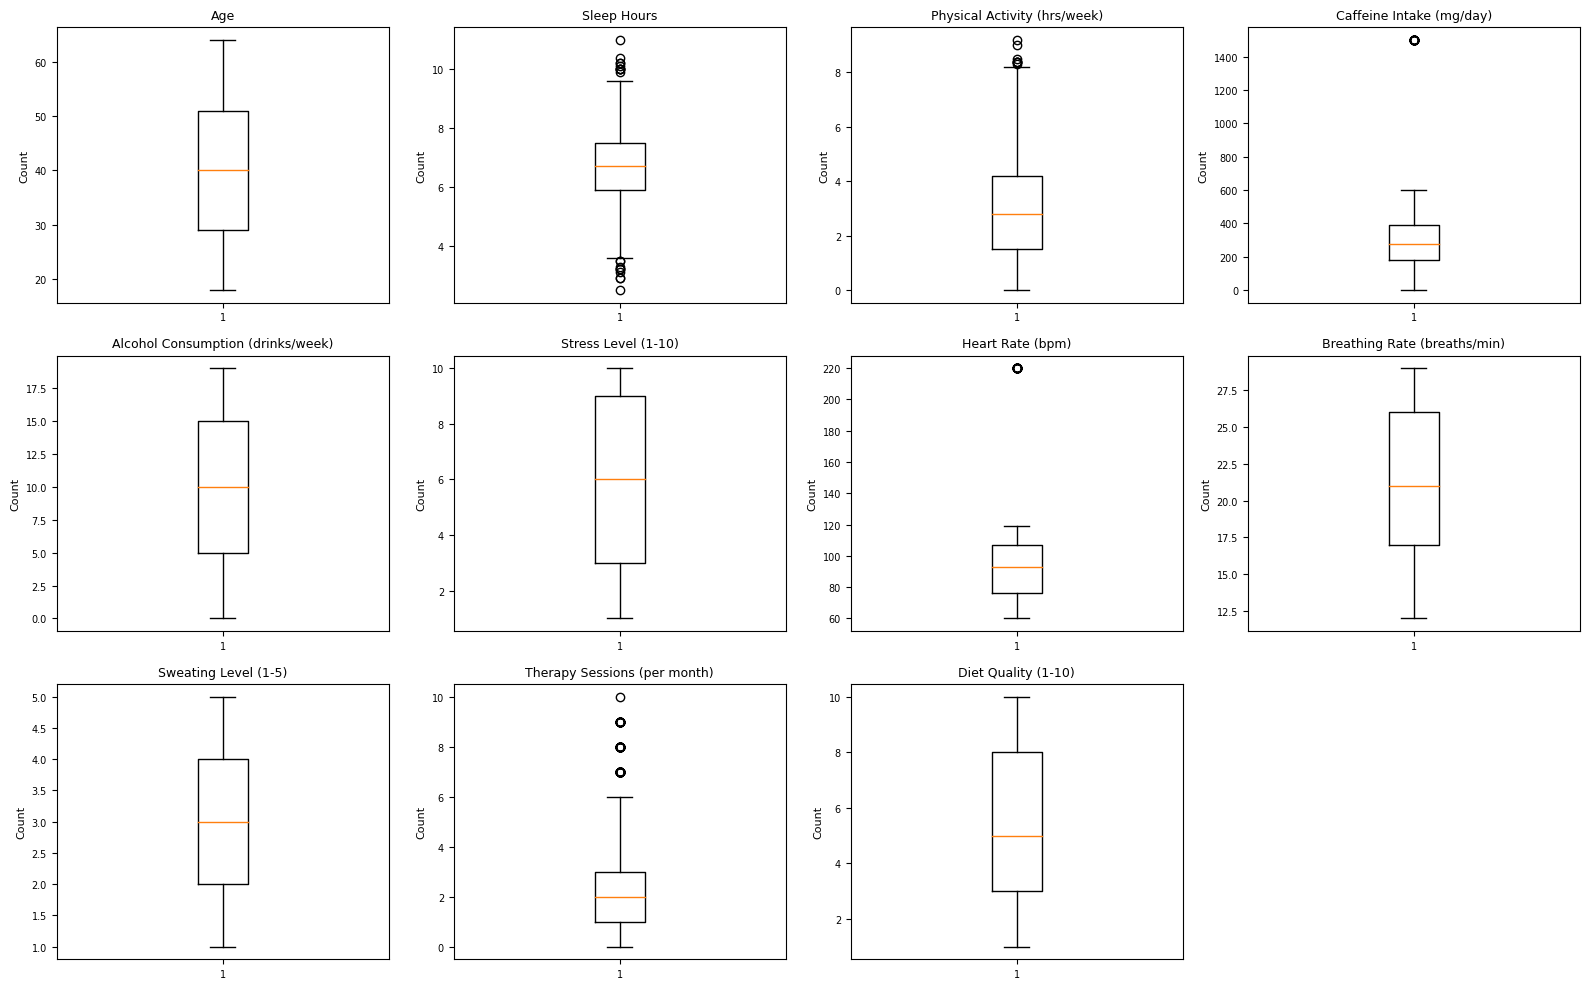

In [16]:
uplot.draw_plots_grid(df_clean,NUM_COLS,plt_type="boxplot",kde_plot=False,n_cols=4,figsize=(16,10))

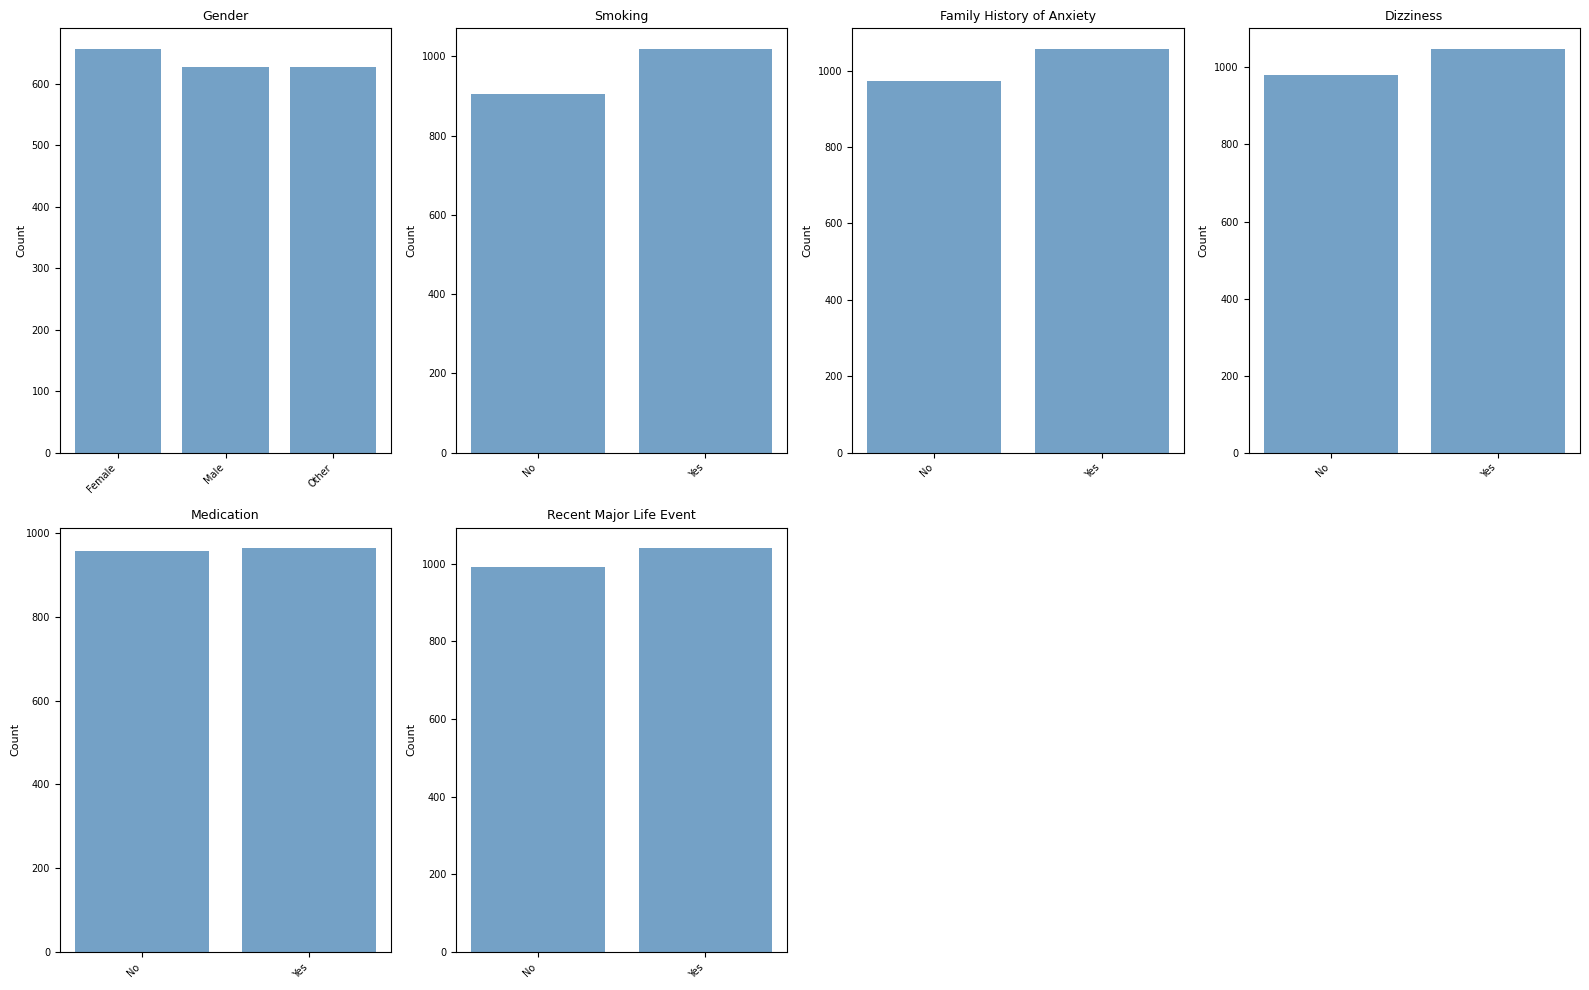

In [17]:
uplot.draw_plots_grid(df_clean,CAT_COLS,plt_type="bar",kde_plot=False,n_cols=4,figsize=(16,10))

<p style="direction: rtl; text-align: right;">
برسی مقادیر پرت Caffeine Intake </p>


In [18]:
df[df['Caffeine Intake (mg/day)'] == 1500]


,Age,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),...,Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-10),Target,is_Anxious,Therapy History
184,30.0,Female,Lawyer,4.8,0.6,1500.0,18,Yes,Yes,8,...,5,No,Yes,6,No,2.0,9.0,1,1,NaN
200,50.0,Female,Lawyer,7.4,1.4,1500.0,1,Yes,Yes,9,...,2,No,No,5,No,7.0,5.0,0,0,NaN
370,46.0,Other,Student,6.9,1.9,1500.0,11,Yes,No,10,...,4,Yes,NaN,1,Yes,8.0,5.0,0,0,NaN
440,28.0,Male,Engineer,5.6,4.2,1500.0,3,No,Yes,10,...,4,No,Yes,2,No,8.0,5.0,0,0,NaN
511,30.0,Female,Teacher,4.2,0.5,1500.0,5,Yes,No,8,...,4,Yes,No,4,Yes,4.0,8.0,1,1,NaN
560,24.0,Male,Athlete,7.4,3.4,1500.0,1,Yes,Yes,10,...,3,No,No,0,No,10.0,5.0,0,0,NaN
671,55.0,Female,Freelancer,4.7,0.7,1500.0,5,Yes,No,9,...,5,No,Yes,2,Yes,6.0,4.0,0,0,NaN
691,49.0,NaN,Chef,7.1,5.7,1500.0,13,Yes,No,6,...,1,No,No,0,No,3.0,2.0,0,0,NaN
719,60.0,Other,Student,8.5,2.5,1500.0,6,Yes,Yes,2,...,2,Yes,Yes,2,No,5.0,2.0,0,0,NaN
752,37.0,Female,Nurse,6.9,5.0,1500.0,4,Yes,No,9,...,2,No,NaN,1,Yes,4.0,5.0,0,0,NaN


<p style="direction: rtl; text-align: right;">
در بررسی میزان مصرف قهوه مشاهده می‌شود که مقدار ۱۵۰۰ میلی‌گرم برای ۳۰ نفر ثبت شده است، در حالی که سایر مقادیر حداکثر ۱۱ بار تکرار شده‌اند. تکرار نسبتاً زیاد یک مقدار مشخص که خود نیز غیرعادی به نظر می‌رسد، می‌تواند نشان‌دهنده خطای ثبت یا ورود داده باشد. بنابراین، این مقدار را به‌عنوان داده‌ای مشکوک در نظر گرفته و برای جلوگیری از تأثیر آن بر نتایج تحلیل، با NaN جایگزین می‌کنیم.</p>


In [19]:
df_clean.loc[df_clean['Caffeine Intake (mg/day)'] == 1500, 'Caffeine Intake (mg/day)'] = np.nan

<p style="direction: rtl; text-align: right;">
برسی مقادیر پرت ضربان قلب</p>


In [20]:
df[df['Heart Rate (bpm)'] == 220]

,Age,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),...,Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-10),Target,is_Anxious,Therapy History
5,53.0,Male,Student,8.7,4.8,324.0,0,Yes,Yes,1,...,5,Yes,NaN,1,Yes,8.0,1.0,0,0,NaN
97,60.0,Other,Lawyer,5.1,4.2,430.0,15,No,No,7,...,4,Yes,No,1,No,2.0,4.0,0,0,NaN
167,40.0,Female,Freelancer,5.7,6.7,290.0,-10,Yes,No,3,...,2,No,Yes,2,Yes,7.0,2.0,0,0,NaN
298,18.0,Other,Chef,7.0,1.2,150.0,1,No,No,3,...,4,Yes,Yes,1,Yes,7.0,2.0,0,0,NaN
335,21.0,Female,Doctor,8.4,2.7,331.0,18,Yes,Yes,2,...,1,No,Yes,3,No,3.0,3.0,0,0,NaN
337,23.0,Other,Engineer,6.9,6.7,456.0,4,Yes,Yes,3,...,4,Yes,No,9,No,3.0,4.0,0,0,NaN
349,58.0,Male,Musician,5.4,3.7,94.0,1,Yes,Yes,10,...,3,No,Yes,2,Yes,5.0,5.0,0,0,NaN
548,53.0,Female,Chef,4.8,0.8,321.0,15,No,No,2,...,4,No,Yes,0,No,7.0,3.0,0,0,NaN
571,52.0,Female,Athlete,6.3,4.7,254.0,17,No,Yes,2,...,1,No,Yes,7,Yes,5.0,2.0,0,0,NaN
619,18.0,Female,Artist,8.1,2.0,168.0,9,No,Yes,8,...,2,Yes,No,3,No,NaN,5.0,0,0,NaN


In [21]:
pd.set_option('display.max_rows', None)
df['Heart Rate (bpm)'].value_counts().sort_index()

60     33
61     30
62     32
63     29
64     35
65     28
66     32
67     22
68     31
69     32
70     37
71     36
72     25
73     26
74     25
75     35
76     25
77     34
78     30
79     24
80     18
81     32
82     36
83     28
84     25
85     34
86     30
87     27
88     24
89     37
90     40
91     39
92     34
93     44
94     32
95     40
96     32
97     27
98     42
99     38
100    32
101    39
102    36
103    36
104    36
105    31
106    32
107    35
108    37
109    27
110    48
111    41
112    32
113    34
114    42
115    35
116    39
117    42
118    45
119    41
220    30
Name: Heart Rate (bpm), dtype: int64

<p style="direction: rtl; text-align: right;">
با توجه به اینکه ضربان قلب معمولاً روندی پیوسته دارد، در این داده مشاهده می‌کنیم که مقدار ضربان قلب به‌صورت ناگهانی از 119 به 220 افزایش یافته است. همچنین از میان 30 نفری که ضربان قلب آن‌ها 220 ثبت شده، تنها 2 نفر دارای وضعیت اضطراب هستند که این الگو نیز غیرعادی به نظر می‌رسد. بنابراین، با توجه به این شواهد، مقدار 220 را به‌عنوان یک مقدار مشکوک در نظر می‌گیریم و برای جلوگیری از تأثیر آن بر تحلیل‌های بعدی، این مقادیر را با NaN جایگزین می‌کنیم.</p>

In [22]:
df_clean.loc[df_clean['Heart Rate (bpm)'] == 220, 'Heart Rate (bpm)'] = np.nan

<p style="direction: rtl; text-align: right;">
برسی مقادیر پرت ستون های Therapy Sessions (per month) -Physical Activity (hrs/week) -Sleep Hours</p>


In [23]:
Q1 = df_clean['Therapy Sessions (per month)'].quantile(0.25)
Q3 = df_clean['Therapy Sessions (per month)'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print('Q1:', Q1)
print('Q3:', Q3)
print('IQR:', IQR)
print('Lower Bound:', lower_bound)
print('Upper Bound:', upper_bound)

outliers_Therapy = df_clean[
    (df_clean['Therapy Sessions (per month)'] < lower_bound) |
    (df_clean['Therapy Sessions (per month)'] > upper_bound)
]

display(outliers_Therapy[['Therapy Sessions (per month)']])

Q1: 1.0
Q3: 3.0
IQR: 2.0
Lower Bound: -2.0
Upper Bound: 6.0


,Therapy Sessions (per month)
29,9
94,7
101,9
105,7
163,7
170,7
182,9
186,9
225,9
247,8


<p style="direction: rtl; text-align: right;">
    در بررسی تعداد جلسات تراپی، مقادیر بالاتر از ۶ جلسه در ماه بر اساس روش IQR به‌عنوان داده‌های پرت شناسایی شدند. با این حال، این مقادیر از نظر مفهومی غیرممکن یا نامعتبر نیستند و می‌توانند نشان‌دهنده افرادی باشند که به جلسات تراپی بیشتری نیاز داشته‌اند. از آنجا که تعداد این داده‌ها نیز قابل توجه است، جایگزین کردن آن‌ها با کران بالا می‌تواند بخشی از اطلاعات واقعی دیتاست را از بین ببرد. بنابراین، در این مرحله این مقادیر را بدون تغییر حفظ می‌کنیم و صرفاً آن‌ها را به‌عنوان مقادیر پرت آماری در نظر می‌گیریم.
</p>

In [24]:
Q1 = df_clean['Physical Activity (hrs/week)'].quantile(0.25)
Q3 = df_clean['Physical Activity (hrs/week)'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print('Q1:', Q1)
print('Q3:', Q3)
print('IQR:', IQR)
print('Lower Bound:', lower_bound)
print('Upper Bound:', upper_bound)

outliers_Physical = df_clean[
    (df_clean['Physical Activity (hrs/week)'] < lower_bound) |
    (df_clean['Physical Activity (hrs/week)'] > upper_bound)
]

display(outliers_Physical[['Physical Activity (hrs/week)']])

Q1: 1.5
Q3: 4.2
IQR: 2.7
Lower Bound: -2.5500000000000007
Upper Bound: 8.25


,Physical Activity (hrs/week)
217,9.2
394,8.4
429,8.4
1359,8.5
1373,8.4
1533,8.3
1891,9.0
1916,8.4


<p style="direction: rtl; text-align: right;">
    در ستون Physical Activity (hrs/week)، بر اساس روش IQR، کران بالای بازه مجاز برابر با 8.25 ساعت در هفته به دست آمد. بررسی داده‌ها نشان داد که تعداد مشاهدات بالاتر از این مقدار کم است و همچنین هیچ‌یک از این افراد در دسته افراد مضطرب قرار ندارند. با توجه به تعداد کم این مشاهدات و نزدیکی مقادیر آن‌ها به کران بالای بازه، تصمیم گرفتیم به‌جای حذف این داده‌ها، مقادیر بالاتر از 8.25 را با مقدار کران بالا جایگزین کنیم. به این ترتیب، ضمن حفظ تعداد رکوردها، اثر مقادیر بسیار بالا بر تحلیل کاهش پیدا می‌کند و داده‌ها در محدوده تعیین‌شده قرار می‌گیرند.
</p>

In [25]:
df_clean['Physical Activity (hrs/week)'] = df_clean['Physical Activity (hrs/week)'].clip(
    lower=lower_bound,
    upper=upper_bound
)


In [26]:
Q1 = df_clean['Sleep Hours'].quantile(0.25)
Q3 = df_clean['Sleep Hours'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print('Q1:', Q1)
print('Q3:', Q3)
print('IQR:', IQR)
print('Lower Bound:', lower_bound)
print('Upper Bound:', upper_bound)

outliers_Sleep = df_clean[
    (df_clean['Sleep Hours'] < lower_bound) |
    (df_clean['Sleep Hours'] > upper_bound)
]

display(outliers_Sleep[['Sleep Hours']])


Q1: 5.9
Q3: 7.5
IQR: 1.5999999999999996
Lower Bound: 3.500000000000001
Upper Bound: 9.899999999999999


,Sleep Hours
8,3.2
140,10.0
452,3.5
554,2.5
696,3.3
739,3.1
1050,2.9
1085,3.2
1124,9.9
1190,10.0


<p style="direction: rtl; text-align: right;">
مقادیر پرت در ستون ساعت خواب از نظر منطقی غیرممکن نیستند و صرفاً بر اساس روش IQR نمی‌توان آن‌ها را داده‌های اشتباه در نظر گرفت. همچنین این مقادیر تنها ۲۰ مورد از ۲۰۳۰ ردیف، یعنی حدود ۱٪ دیتاست را تشکیل می‌دهند. بنابراین برای حفظ اطلاعات موجود و کاهش تأثیر مقادیر پرت، از روش Capping با استفاده از کران پایین و بالا استفاده می‌کنیم.</p>

In [27]:
df_clean['Sleep Hours'] = df_clean['Sleep Hours'].clip(
    lower=lower_bound,
    upper=upper_bound
)


<p style="direction: rtl; text-align: right;">
برسی مقادیر NAN</p>

In [28]:
miss=df_clean.isna().sum()
miss_pct = (miss / len(df_clean) * 100).round(2)
missing_table = pd.DataFrame({'miss': miss, 'miss_pct': miss_pct})
print(missing_table[missing_table['miss']>0].sort_values('miss',ascending=False))

                                   miss  miss_pct
Therapy History                    1827     90.00
Caffeine Intake (mg/day)            124      6.11
Gender                              119      5.86
Medication                          109      5.37
Smoking                             106      5.22
Diet Quality (1-10)                  78      3.84
Sleep Hours                          76      3.74
Age                                  62      3.05
Physical Activity (hrs/week)         40      1.97
Alcohol Consumption (drinks/week)    40      1.97
Stress Level (1-10)                  30      1.48
Heart Rate (bpm)                     30      1.48


<p style="direction: rtl; text-align: right;">
برای داده‌های کتگوریکال، مقادیر گمشده را با استفاده از مقدار مد (Mode)، یعنی پرتکرارترین مقدار هر ستون، جایگزین می‌کنیم. این روش با حفظ تعداد رکوردهای دیتاست، از حذف داده‌ها جلوگیری می‌کند.</p>

In [29]:
categorical_cols = [
    'Gender',
    'Medication',
    'Smoking'
]

for col in CAT_COLS:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])


In [30]:
df_clean[NUM_COLS].skew()


Age                                  0.107037
Sleep Hours                         -0.186210
Physical Activity (hrs/week)         0.397708
Caffeine Intake (mg/day)             0.324888
Alcohol Consumption (drinks/week)   -0.048695
Stress Level (1-10)                 -0.183242
Heart Rate (bpm)                    -0.132409
Breathing Rate (breaths/min)        -0.129483
Sweating Level (1-5)                -0.098633
Therapy Sessions (per month)         1.053035
Diet Quality (1-10)                  0.124901
dtype: float64

<p style="direction: rtl; text-align: right;">
حال چولگی داده هارا بررسی میکنیم
</p>

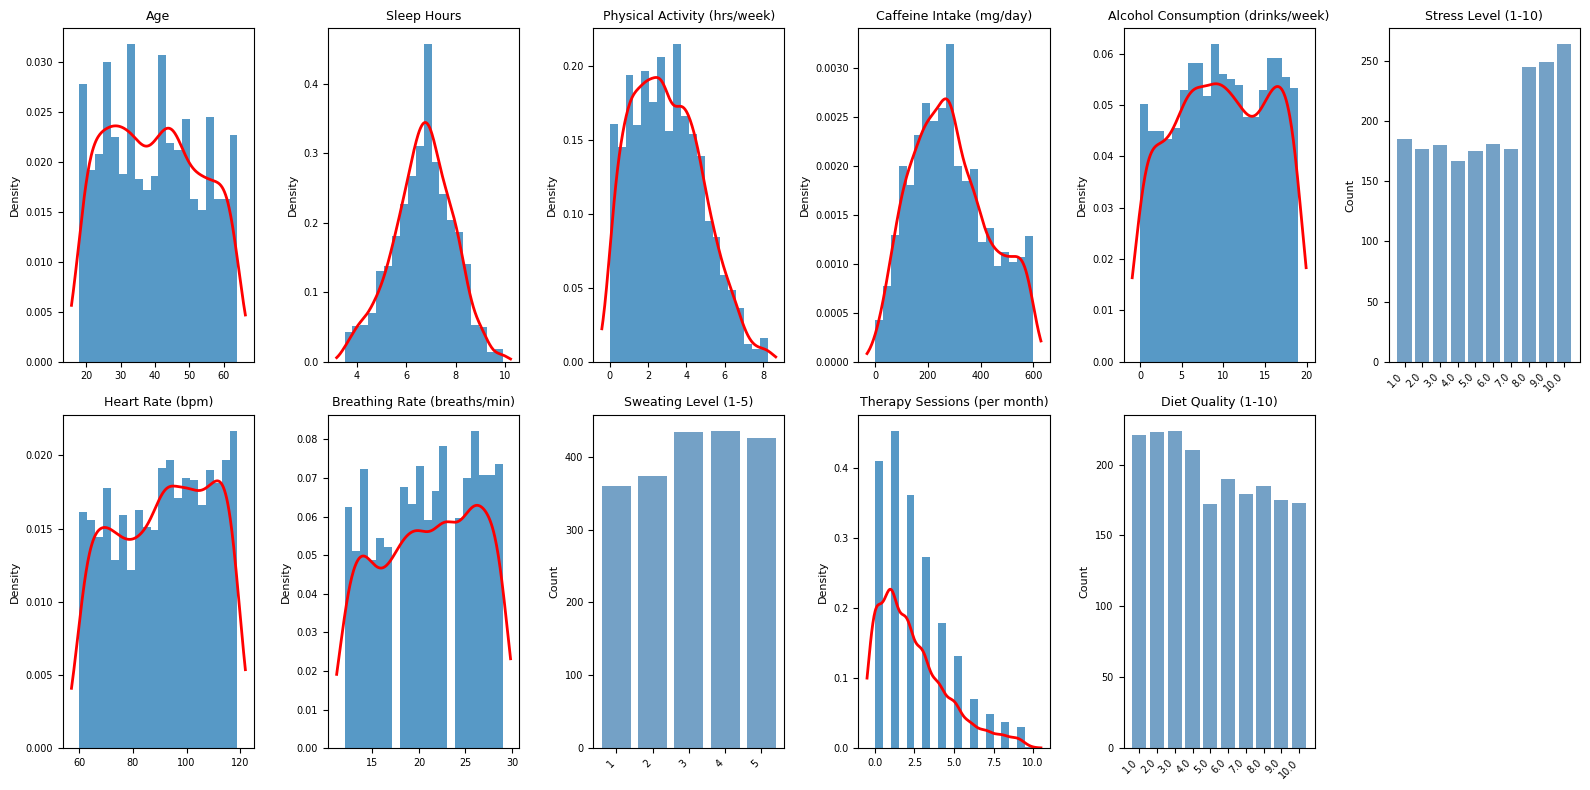

In [31]:
uplot.draw_plots_grid(df_clean,NUM_COLS)

In [32]:
for col_name in NUM_COLS:
    print(col_name,(40-len(col_name))*" ","mean & median : ", df_clean[col_name].mean().round(2)," | ",df_clean[col_name].median().round(2))

Age                                       mean & median :  39.92  |  40.0
Sleep Hours                               mean & median :  6.67  |  6.7
Physical Activity (hrs/week)              mean & median :  2.98  |  2.8
Caffeine Intake (mg/day)                  mean & median :  287.49  |  275.0
Alcohol Consumption (drinks/week)         mean & median :  9.79  |  10.0
Stress Level (1-10)                       mean & median :  5.89  |  6.0
Heart Rate (bpm)                          mean & median :  91.16  |  92.0
Breathing Rate (breaths/min)              mean & median :  20.96  |  21.0
Sweating Level (1-5)                      mean & median :  3.1  |  3.0
Therapy Sessions (per month)              mean & median :  2.36  |  2.0
Diet Quality (1-10)                       mean & median :  5.23  |  5.0


<p style="direction: rtl; text-align: right;">
عمدتا در داده ها چولگی مشاهده نمی شود ولی با توجه به اینکه میانه و میانگین برابر است, برای جایگذاری از میانه استفاده می‌کنیم.
</p>

In [33]:
for col in NUM_COLS:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

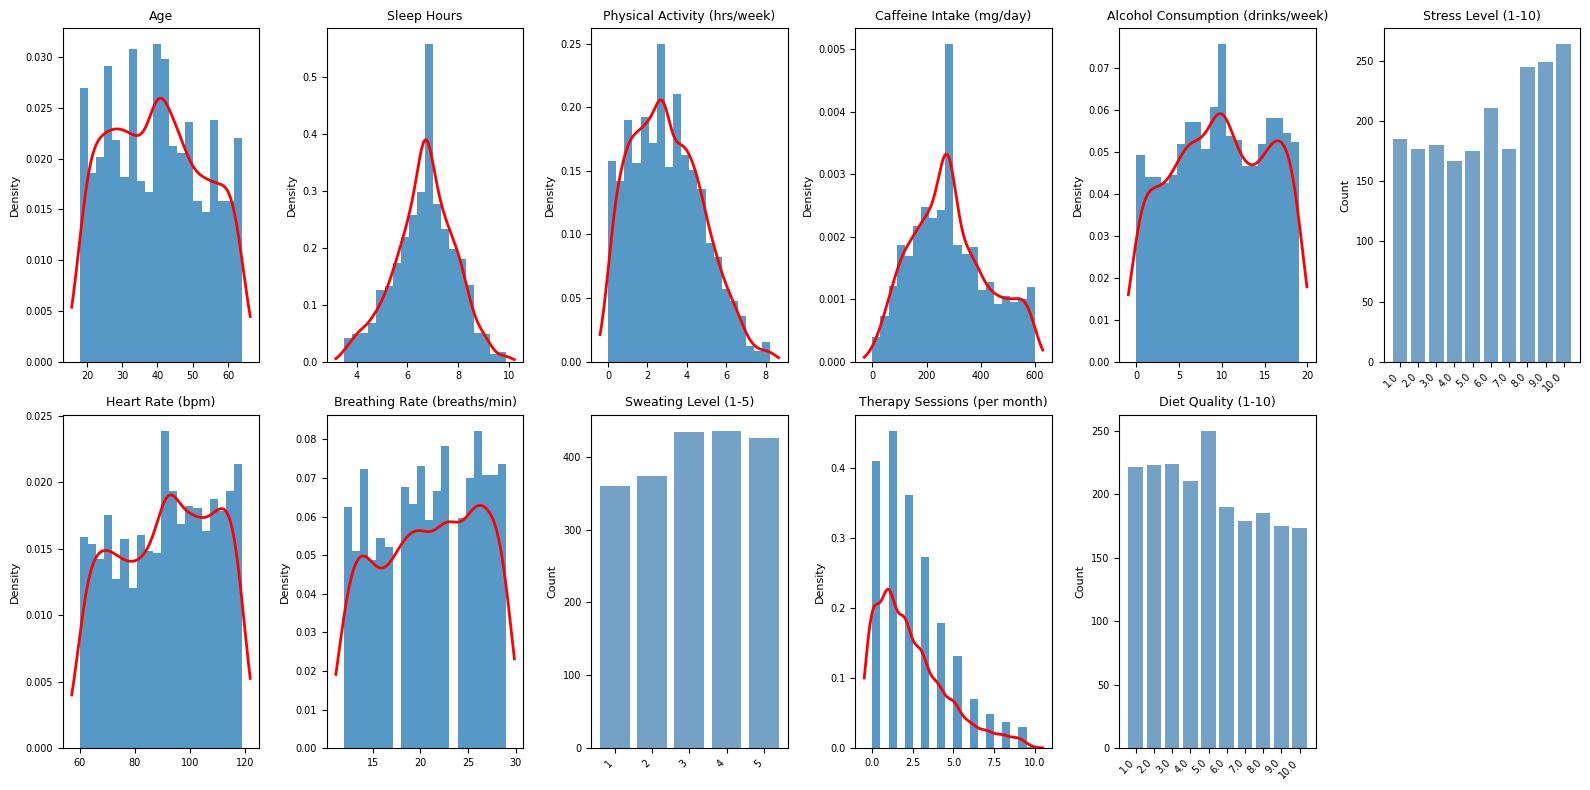

In [34]:
uplot.draw_plots_grid(df_clean,NUM_COLS)

In [35]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2030 entries, 0 to 2029
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                2030 non-null   float64
 1   Gender                             2030 non-null   object 
 2   Occupation                         2030 non-null   object 
 3   Sleep Hours                        2030 non-null   float64
 4   Physical Activity (hrs/week)       2030 non-null   float64
 5   Caffeine Intake (mg/day)           2030 non-null   float64
 6   Alcohol Consumption (drinks/week)  2030 non-null   float64
 7   Smoking                            2030 non-null   object 
 8   Family History of Anxiety          2030 non-null   object 
 9   Stress Level (1-10)                2030 non-null   float64
 10  Heart Rate (bpm)                   2030 non-null   float64
 11  Breathing Rate (breaths/min)       2030 non-null   int64

In [36]:
df_clean.describe().round(2)

,Age,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Therapy Sessions (per month),Diet Quality (1-10),Anxiety Level (1-10),Target
count,2030.00,2030.00,2030.00,2030.00,2030.00,2030.00,2030.00,2030.00,2030.00,2030.00,2030.00,2030.00,2030.0
mean,39.92,6.67,2.97,286.72,9.79,5.90,91.17,20.96,3.10,2.36,5.23,3.92,0.1
std,13.04,1.19,1.78,140.97,5.63,2.94,17.37,5.18,1.39,2.15,2.83,2.14,0.3
min,18.00,3.50,0.00,0.00,0.00,1.00,60.00,12.00,1.00,0.00,1.00,1.00,0.0
25%,29.00,6.00,1.60,183.00,5.00,3.00,76.00,17.00,2.00,1.00,3.00,2.00,0.0
50%,40.00,6.70,2.80,275.00,10.00,6.00,92.00,21.00,3.00,2.00,5.00,4.00,0.0
75%,50.00,7.50,4.20,378.00,15.00,9.00,106.00,26.00,4.00,3.00,8.00,5.00,0.0
max,64.00,9.90,8.25,599.00,19.00,10.00,119.00,29.00,5.00,10.00,10.00,10.00,1.0


<p style="direction: rtl; text-align: right;">
حال یکبار دیگر چولگی را بررسی میکنیم
</p>

In [37]:

df_clean[NUM_COLS].skew()


Age                                  0.108157
Sleep Hours                         -0.192455
Physical Activity (hrs/week)         0.407397
Caffeine Intake (mg/day)             0.351253
Alcohol Consumption (drinks/week)   -0.051423
Stress Level (1-10)                 -0.186204
Heart Rate (bpm)                    -0.135528
Breathing Rate (breaths/min)        -0.129483
Sweating Level (1-5)                -0.098633
Therapy Sessions (per month)         1.053035
Diet Quality (1-10)                  0.136846
dtype: float64

<p style="direction: rtl; text-align: right;">
حال نرمال بودن ستون های عددی را بررسی می‌کنیم(شاپیرو)
</p>

In [38]:
for col in NUM_COLS:
    stat, p = stats.shapiro(df_clean[col])
    print(f"{col}, stats = {stat:.4f}, p = {p:.4f}")

Age, stats = 0.9618, p = 0.0000
Sleep Hours, stats = 0.9931, p = 0.0000
Physical Activity (hrs/week), stats = 0.9752, p = 0.0000
Caffeine Intake (mg/day), stats = 0.9737, p = 0.0000
Alcohol Consumption (drinks/week), stats = 0.9558, p = 0.0000
Stress Level (1-10), stats = 0.9242, p = 0.0000
Heart Rate (bpm), stats = 0.9530, p = 0.0000
Breathing Rate (breaths/min), stats = 0.9471, p = 0.0000
Sweating Level (1-5), stats = 0.8913, p = 0.0000
Therapy Sessions (per month), stats = 0.8845, p = 0.0000
Diet Quality (1-10), stats = 0.9374, p = 0.0000


<h1 style="direction: rtl; text-align: right;">
 ستون Therapy History </h1>

In [39]:
df_clean['Therapy History'].unique()

array(['Group Therapy', nan, 'Psychodynamic Therapy',
       'Cognitive Behavioral Therapy (CBT)', 'No previous history'],
      dtype=object)

In [40]:
df_clean['Therapy History'] = df_clean['Therapy History'].str.strip()

therapy_mapping = {
    'Group Therapy': 1,
    'Psychodynamic Therapy': 2,
    'Cognitive Behavioral Therapy (CBT)': 3,
    'No previous history': 4
}

df_clean['Therapy History'] = (
    df_clean['Therapy History']
    .map(therapy_mapping)
    .fillna(0)
    .astype(int)
)

In [41]:
df_clean.to_csv("cleaned_data.csv",index=False)

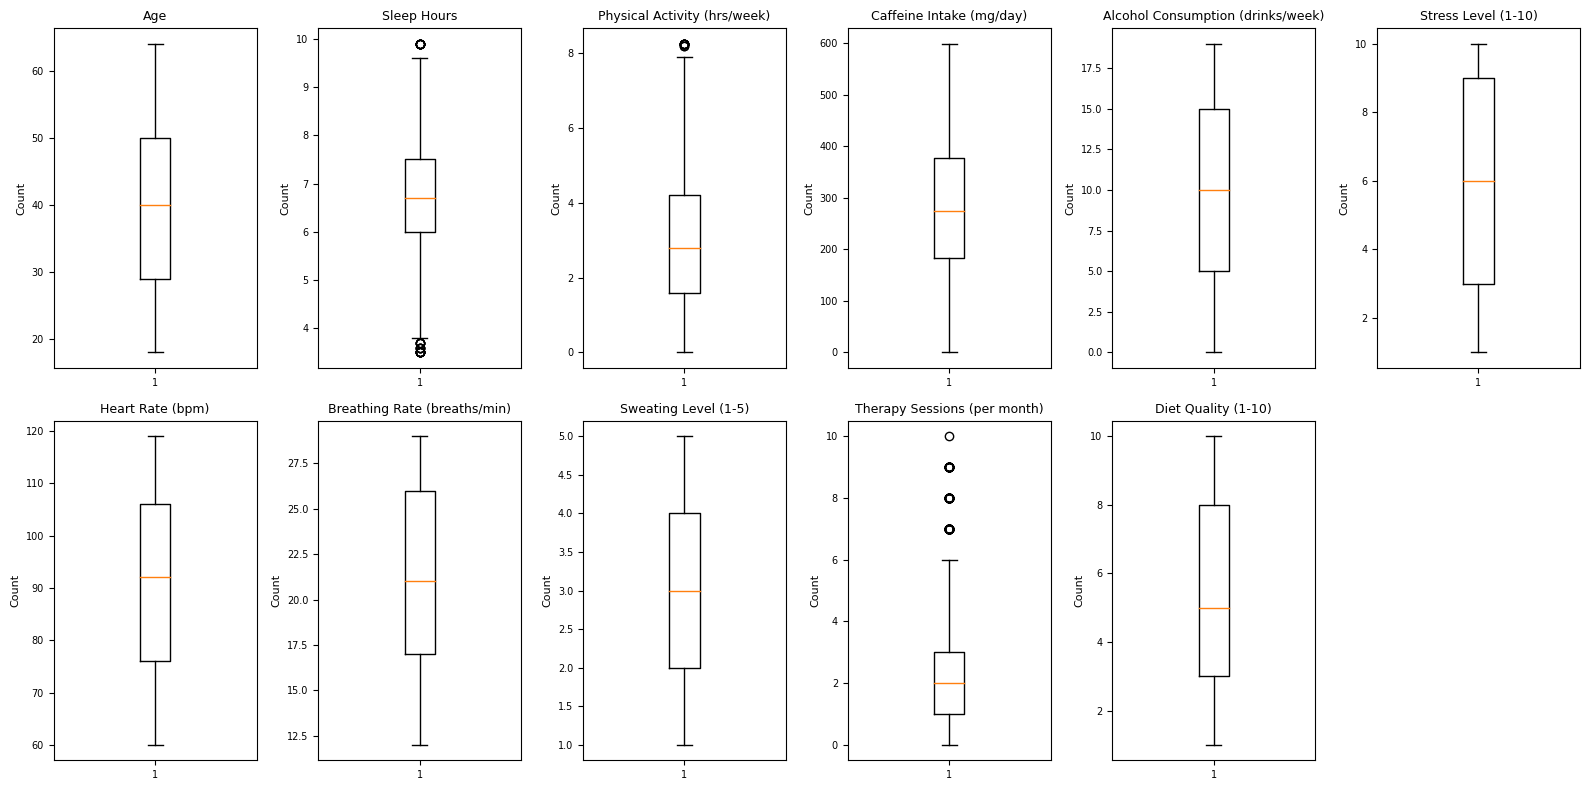

In [42]:
uplot.draw_plots_grid(df_clean,NUM_COLS,plt_type="boxplot",kde_plot=False)

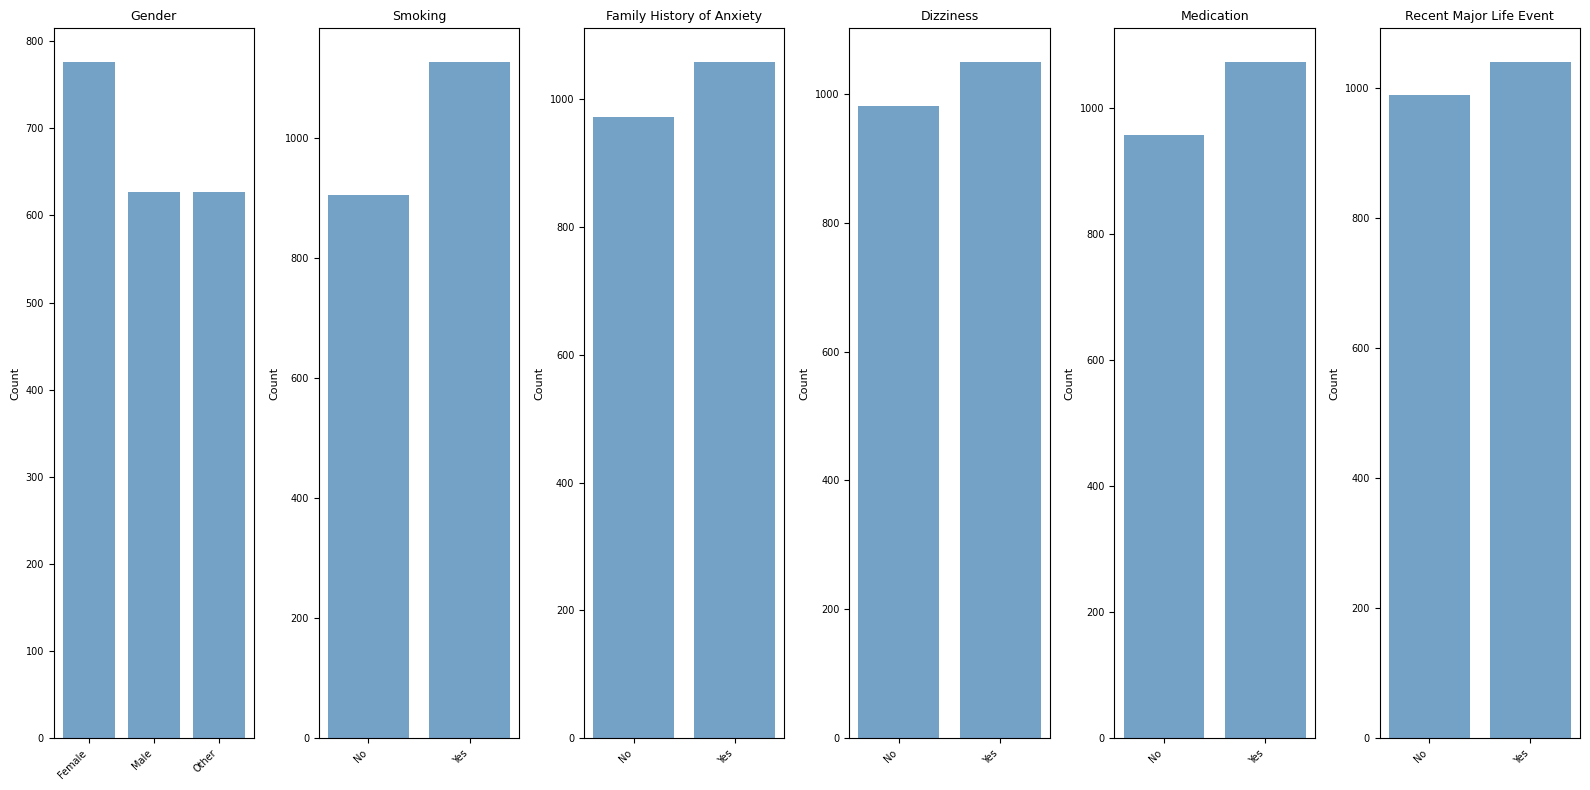

In [43]:
uplot.draw_plots_grid(df_clean,CAT_COLS,plt_type="bar",kde_plot=False)

In [44]:
df_clean.describe()

,Age,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Therapy Sessions (per month),Diet Quality (1-10),Anxiety Level (1-10),Target,Therapy History
count,2030.000000,2030.000000,2030.000000,2030.000000,2030.000000,2030.000000,2030.000000,2030.000000,2030.000000,2030.000000,2030.000000,2030.000000,2030.000000,2030.00000
mean,39.924138,6.672808,2.972365,286.724138,9.790640,5.895567,91.174877,20.955665,3.095567,2.359113,5.225123,3.922660,0.103448,0.25468
std,13.039847,1.189414,1.778445,140.971150,5.629081,2.938491,17.370246,5.182524,1.392697,2.148642,2.829309,2.139176,0.304619,0.84924
min,18.000000,3.500000,0.000000,0.000000,0.000000,1.000000,60.000000,12.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.00000
25%,29.000000,6.000000,1.600000,183.000000,5.000000,3.000000,76.000000,17.000000,2.000000,1.000000,3.000000,2.000000,0.000000,0.00000
50%,40.000000,6.700000,2.800000,275.000000,10.000000,6.000000,92.000000,21.000000,3.000000,2.000000,5.000000,4.000000,0.000000,0.00000
75%,50.000000,7.500000,4.200000,378.000000,15.000000,9.000000,106.000000,26.000000,4.000000,3.000000,8.000000,5.000000,0.000000,0.00000
max,64.000000,9.900000,8.250000,599.000000,19.000000,10.000000,119.000000,29.000000,5.000000,10.000000,10.000000,10.000000,1.000000,4.00000
